# Best-Practices Handbook for Volatility Modeling

## Table of Contents

1.  **Overfitting**
    *   Definition
    *   Description
    *   Demonstration
    *   Diagram
    *   Diagnosis
    *   Damage
    *   Directions

2.  **Multicollinearity**
    *   Definition
    *   Description
    *   Demonstration
    *   Diagram
    *   Diagnosis
    *   Damage
    *   Directions

3.  **Skewness**
    *   Definition
    *   Description
    *   Demonstration
    *   Diagram
    *   Diagnosis
    *   Damage
    *   Directions

4.  **Prioritizing Factors**
    *   Definition
    *   Description
    *   Demonstration
    *   Diagram
    *   Diagnosis
    *   Damage
    *   Directions

## Summary of Best-Practices Handbook

*   Detailed overview of all problems and their solutions.
*   References

In [ ]:
import kagglehub
path = kagglehub.dataset_download("headsortails/kaggle-weekly-gpu-quotas")

## 1. Overfitting

### Definition
Overfitting occurs when a statistical or machine learning model learns the training data too well, capturing noise and specific patterns that are not representative of the true underlying relationship in the data. This leads to poor generalization performance on unseen data. Mathematically, for a model $h(x)$ trying to approximate a true function $f(x)$ with noise $\epsilon$, we have $y = f(x) + \epsilon$. An overfitted model $h(x)$ will minimize the training error $E_{train} = \frac{1}{N}\sum_{i=1}^{N}(h(x_i) - y_i)^2$ to a very small value, but will have a high test error $E_{test}$ on new data points.

### Description
An overfitted model essentially 'memorizes' the training examples rather than learning the general principles. It performs exceptionally well on the data it was trained on but fails to make accurate predictions when presented with new, previously unseen data.

### Demonstration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(0)

# Generate synthetic data for demonstration
def true_function(X):
    return np.sin(X) + np.cos(X/2)

X = np.random.rand(100) * 10 - 5 # 100 points between -5 and 5
y_true = true_function(X)
y = y_true + np.random.randn(100) * 0.5 # Add some noise

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_sorted = np.sort(X_train)
y_train_sorted = y_train[np.argsort(X_train)]

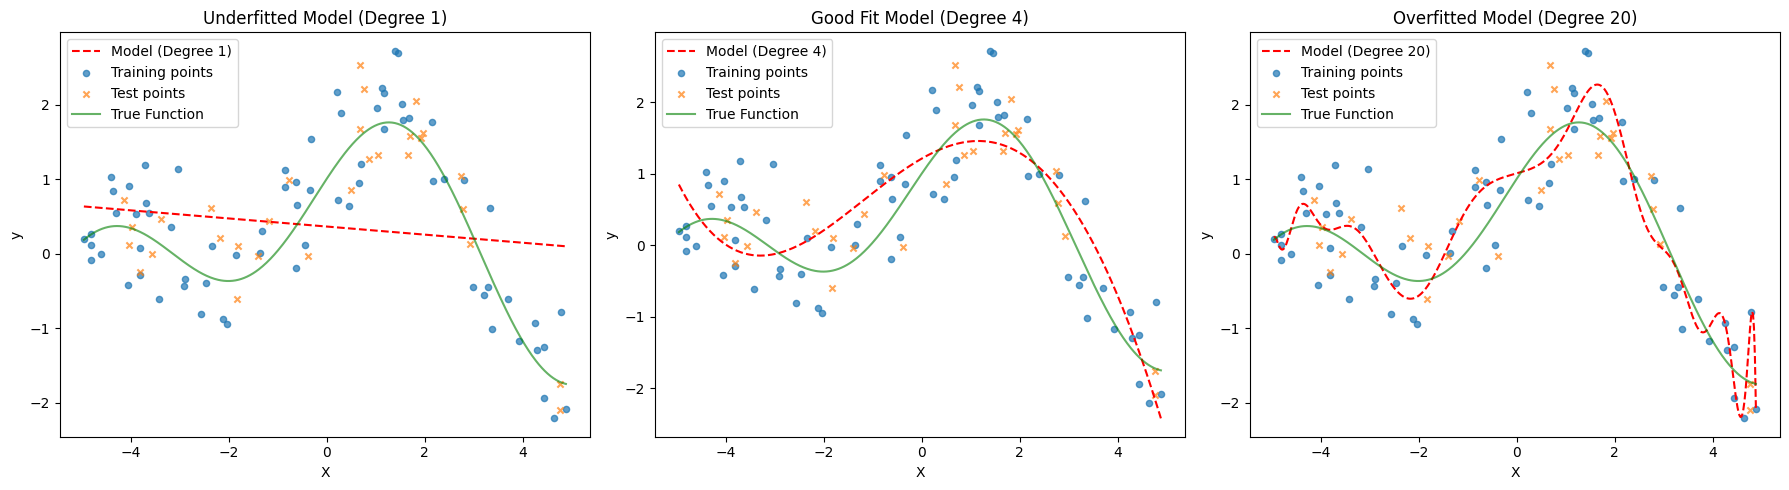

In [2]:
# Function to plot models
def plot_model(degree, ax, X_train, y_train, X_test, y_test):
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression)
    ])
    pipeline.fit(X_train[:, np.newaxis], y_train)

    # Evaluate on training and test sets
    y_train_pred = pipeline.predict(X_train[:, np.newaxis])
    y_test_pred = pipeline.predict(X_test[:, np.newaxis])

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    X_plot = np.linspace(X.min(), X.max(), 500)
    y_plot = pipeline.predict(X_plot[:, np.newaxis])

    ax.plot(X_plot, y_plot, label=f'Model (Degree {degree})', color='red', linestyle='--')
    ax.scatter(X_train, y_train, s=20, label='Training points', alpha=0.7)
    ax.scatter(X_test, y_test, s=20, label='Test points', alpha=0.7, marker='x')
    ax.plot(X_plot, true_function(X_plot), label='True Function', color='green', alpha=0.6)
    ax.set_title(f'Degree {degree} Polynomial (Train RMSE: {rmse_train:.2f}, Test RMSE: {rmse_test:.2f})')
    ax.legend()
    ax.set_xlabel('X')
    ax.set_ylabel('y')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Underfitted Model (e.g., Degree 1 - Linear)
plot_model(1, axes[0], X_train, y_train, X_test, y_test)
axes[0].set_title('Underfitted Model (Degree 1)')

# Good Fit Model (e.g., Degree 4)
plot_model(4, axes[1], X_train, y_train, X_test, y_test)
axes[1].set_title('Good Fit Model (Degree 4)')

# Overfitted Model (e.g., Degree 20)
plot_model(20, axes[2], X_train, y_train, X_test, y_test)
axes[2].set_title('Overfitted Model (Degree 20)')

plt.tight_layout()
plt.show()

### Diagram

The demonstration above visually illustrates overfitting. In the 'Overfitted Model (Degree 20)' plot, the red dashed line (our model) tries to pass through almost every training data point, showing extreme wiggles. While its training RMSE might be very low, its test RMSE is significantly higher, indicating poor generalization. In contrast, the 'Good Fit Model' (Degree 4) captures the general trend without perfectly fitting the noise, leading to good performance on both training and test data. The 'Underfitted Model' (Degree 1) is too simple and cannot capture the underlying pattern effectively, resulting in high error on both sets.

### Diagnosis

Overfitting is typically identified by a significant disparity between a model's performance on the training data versus its performance on unseen test data. Key diagnostic signs include:

1.  **High Training Accuracy / Low Test Accuracy**: The model performs very well on the training set (e.g., low training error, high training R-squared) but significantly worse on the validation or test set.
2.  **Complex Model**: Models with many parameters or high degrees of freedom (e.g., high-degree polynomials, deep neural networks with many layers/neurons, decision trees with excessive depth) are more prone to overfitting.
3.  **Visual Inspection**: For simpler models or when plotting predictions, an overfitted model's curve will often pass through or very close to most training points, exhibiting erratic behavior that doesn't follow the general trend.
4.  **Cross-Validation**: Using techniques like k-fold cross-validation can reveal inconsistent performance across different folds, indicating that the model's performance is highly dependent on the specific training data split.

### Damage

Overfitting leads to models that are unreliable and impractical for real-world application. The primary damage includes:

1.  **Poor Predictive Performance**: The model will make inaccurate predictions on new, unseen data, leading to flawed decisions or strategies, especially critical in financial modeling for derivatives pricing and risk management.
2.  **Reduced Generalizability**: The model lacks the ability to generalize its learned patterns to new scenarios, making it useless outside of the specific training environment.
3.  **Wasted Resources**: Time and computational resources spent training a complex, overfitted model that ultimately performs poorly on real data are wasted.
4.  **Loss of Trust**: In a professional setting like a derivatives desk, consistently inaccurate models can erode confidence from traders and risk managers, impacting the perceived expertise and reliability of the quantitative team.

### Directions

Several strategies can be employed to combat overfitting and improve a model's generalization capabilities:

1.  **More Data**: Increasing the size and diversity of the training dataset can help the model learn more robust patterns rather than memorizing noise.
2.  **Feature Selection/Engineering**: Reducing the number of features or creating more relevant features can simplify the model and reduce its capacity to overfit.
3.  **Regularization**: Techniques like L1 (Lasso) and L2 (Ridge) regularization add a penalty to the loss function for large coefficient values, effectively shrinking them and making the model less sensitive to individual data points.
4.  **Cross-Validation**: Using cross-validation helps to estimate the model's performance on unseen data more robustly and can guide hyperparameter tuning to prevent overfitting.
5.  **Simpler Models**: Choosing a less complex model architecture (e.g., lower-degree polynomial, shallower decision tree, fewer layers in a neural network) can inherently reduce the risk of overfitting.
6.  **Early Stopping**: For iterative learning algorithms (like neural networks or gradient boosting), training can be stopped when the performance on a validation set starts to degrade, even if the training set performance is still improving.
7.  **Ensemble Methods**: Combining multiple models (e.g., Random Forests, Gradient Boosting Machines) can often reduce overfitting compared to a single complex model.

## 2. Multicollinearity

### Definition
Multicollinearity refers to a phenomenon in multiple regression where two or more predictor variables are highly correlated with each other. This high correlation can lead to unreliable and unstable estimates of the regression coefficients. Mathematically, in a linear regression model $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$, multicollinearity occurs when there is a strong linear relationship among the independent variables $X_1, X_2, \dots, X_p$.

### Description
When predictor variables are highly correlated, it becomes difficult for the model to estimate the individual effect of each predictor on the response variable. The coefficients might fluctuate wildly with small changes in the data, making them hard to interpret and leading to less precise statistical inferences.

### Demonstration

In [6]:
import pandas as pd
import os
import statsmodels.api as sm
import numpy as np # Import numpy as it's used in synthetic data generation
import kagglehub # Import kagglehub

# Download the dataset using kagglehub
path = kagglehub.dataset_download("headsortails/kaggle-weekly-gpu-quotas")
print(f"Dataset downloaded to: {path}")

# The 'path' variable should contain the path to the downloaded dataset from kagglehub
# Assuming the dataset is a CSV file within the downloaded path.
# Let's inspect the contents of the path first.

dataset_files = os.listdir(path)
print(f"Files in the dataset directory: {dataset_files}")

# Assuming 'kaggle-weekly-gpu-quotas.csv' is the main data file
data_file = None
for f in dataset_files:
    if f.endswith('.csv'):
        data_file = f
        break

if data_file:
    df = pd.read_csv(os.path.join(path, data_file))
    print("Dataset loaded successfully.")
    display(df.head())
else:
    print("No CSV file found in the dataset directory. Generating synthetic data for demonstration.")
    # Generate synthetic data if no suitable CSV is found
    np.random.seed(42)
    X1 = np.random.rand(100) * 10
    X2 = X1 * 0.9 + np.random.rand(100) * 2  # Highly correlated with X1
    X3 = np.random.rand(100) * 5
    y = 2*X1 + 3*X3 + np.random.randn(100) * 5
    df = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'y': y})
    print("Synthetic data generated.")
    display(df.head())

100%|██████████| 830/830 [00:00<00:00, 1.84MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/headsortails/kaggle-weekly-gpu-quotas/versions/127
Files in the dataset directory: ['kaggle_gpu_hours.csv']
Dataset loaded successfully.


,date,gpu_hours
0,2020-08-08,39.0
1,2020-08-15,36.0
2,2020-08-22,43.0
3,2020-08-29,41.0
4,2020-09-05,42.0


In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Check current df columns. Kernel state shows df has 'date' and 'gpu_hours'.
# The previous cell (27b74358) successfully loaded 'kaggle_gpu_hours.csv'.

df_working = df.copy() # Work on a copy of the global df

# If 'gpu_hours' is available, create synthetic correlated features
if 'gpu_hours' in df_working.columns:
    # Ensure 'date' column is dropped or handled if it's not numerical for regression
    if 'date' in df_working.columns:
        df_working = df_working.drop(columns=['date'])

    # Use 'gpu_hours' as a base feature
    df_working['Feature1_GPU'] = df_working['gpu_hours']

    # Create a highly correlated synthetic feature
    np.random.seed(42) # for reproducibility
    df_working['Feature2_Correlated_GPU'] = df_working['Feature1_GPU'] * 0.95 + np.random.randn(len(df_working)) * 0.5

    # Create another, less correlated feature (or noise) for the model
    df_working['Feature3_Independent'] = np.random.rand(len(df_working)) * 10

    # Create a synthetic target variable based on these features
    df_working['Target_GPU'] = (df_working['Feature1_GPU'] * 0.5 +
                                df_working['Feature3_Independent'] * 0.2 +
                                np.random.randn(len(df_working)) * 5)

    X_cols = ['Feature1_GPU', 'Feature2_Correlated_GPU', 'Feature3_Independent']
    y_col = 'Target_GPU'

    # Drop NaNs if any were introduced by operations
    df_working = df_working.dropna(subset=X_cols + [y_col])

elif 'X1' in df_working.columns and 'X2' in df_working.columns:
    # This block would execute if synthetic data from cell 27b74358's 'else' branch was used
    X_cols = ['X1', 'X2', 'X3']
    y_col = 'y'
    df_working = df_working.dropna(subset=X_cols + [y_col])

else:
    # Fallback: if no suitable columns are found, generate completely synthetic data
    print("No suitable columns found in the loaded dataset. Generating completely synthetic data for demonstration.")
    np.random.seed(42)
    X1 = np.random.rand(100) * 10
    X2 = X1 * 0.9 + np.random.rand(100) * 2  # Highly correlated with X1
    X3 = np.random.rand(100) * 5
    y_synth = 2*X1 + 3*X3 + np.random.randn(100) * 5
    df_working = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'y': y_synth})
    X_cols = ['X1', 'X2', 'X3']
    y_col = 'y'

# Update the global df with the df_working for subsequent cells to use the modified DataFrame
df = df_working.copy()

# Perform regression with all potentially correlated variables
X = df[X_cols]
y = df[y_col]

X = sm.add_constant(X) # Add an intercept term
model_full = sm.OLS(y, X).fit()
print("\nRegression with all features:")
print(model_full.summary())

# Demonstrate impact by removing one correlated variable
# Check for the specific correlated feature created or from synthetic fallback
if 'Feature2_Correlated_GPU' in X_cols:
    X_to_remove = 'Feature2_Correlated_GPU'
elif 'X2' in X_cols:
    X_to_remove = 'X2'
else:
    X_to_remove = None

if X_to_remove and len(X_cols) > 1:
    X_reduced_cols = [col for col in X_cols if col != X_to_remove]
    X_reduced = df[X_reduced_cols]
    X_reduced = sm.add_constant(X_reduced)
    model_reduced = sm.OLS(y, X_reduced).fit()
    print(f"\nRegression after removing one highly correlated feature ({X_to_remove}):")
    print(model_reduced.summary())
else:
    print("\nNot enough correlated features or specific correlated feature not present to show reduction.")



Regression with all features:
                            OLS Regression Results                            
Dep. Variable:             Target_GPU   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     29.09
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.75e-15
Time:                        08:29:16   Log-Likelihood:                -575.77
No. Observations:                 191   AIC:                             1160.
Df Residuals:                     187   BIC:                             1173.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

### Diagram

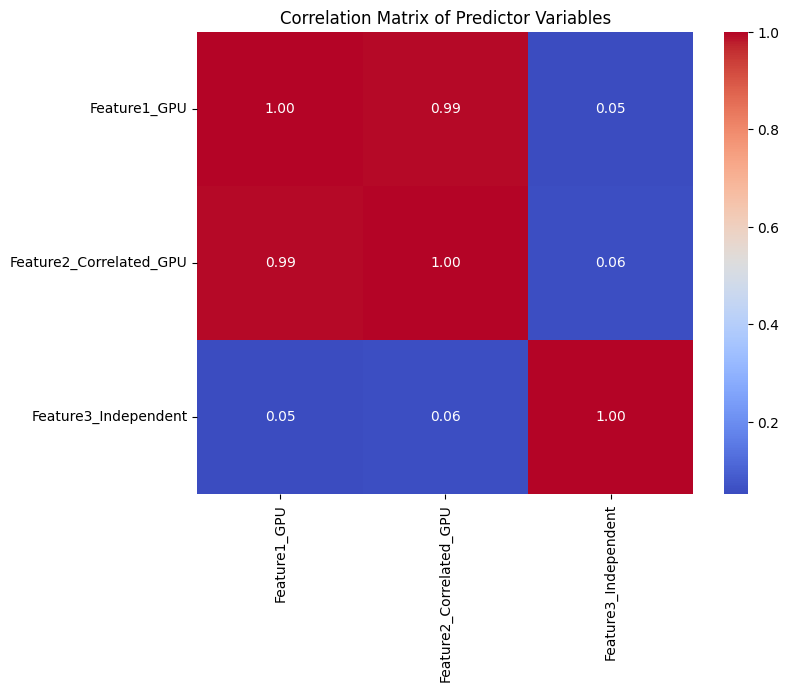

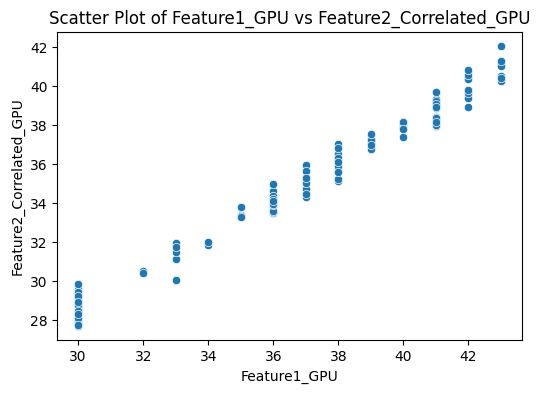

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[X_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Predictor Variables')
plt.show()

# Scatter plots for highly correlated pairs, using the actual features created
if 'Feature1_GPU' in X_cols and 'Feature2_Correlated_GPU' in X_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x='Feature1_GPU', y='Feature2_Correlated_GPU', data=df)
    plt.title('Scatter Plot of Feature1_GPU vs Feature2_Correlated_GPU')
    plt.show()
elif 'X1' in X_cols and 'X2' in X_cols: # Fallback for synthetic data
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x='X1', y='X2', data=df)
    plt.title('Scatter Plot of X1 vs X2 (Highly Correlated)')
    plt.show()


### Diagnosis

Diagnosing multicollinearity is crucial to ensure the reliability of regression models. Common diagnostic methods include:

1.  **High Correlation Coefficients**: Examine the correlation matrix between independent variables. Absolute correlation coefficients above 0.7-0.8 often indicate a problem.
2.  **Variance Inflation Factor (VIF)**: VIF measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. A VIF value greater than 5 or 10 is commonly considered problematic, indicating severe multicollinearity. It is calculated as $VIF_j = \frac{1}{1 - R_j^2}$, where $R_j^2$ is the $R^2$ value from a regression of $X_j$ on all other independent variables.
3.  **Changes in Coefficients**: Observe large changes in regression coefficients (and their signs) when adding or removing a predictor variable.
4.  **Large Standard Errors**: Multicollinearity inflates the standard errors of the regression coefficients, making it difficult to reject the null hypothesis that a coefficient is zero (i.e., reduces statistical significance).
5.  **Low p-values for individual coefficients but high overall R-squared**: The overall model might be statistically significant (high $R^2$), but individual predictors lack significance due to inflated standard errors.

### Damage

The presence of multicollinearity can severely undermine the integrity and usefulness of a regression model, particularly in contexts like derivatives pricing and risk management:

1.  **Unreliable Coefficient Estimates**: The estimated regression coefficients become highly sensitive to small changes in the data, leading to unstable and untrustworthy parameter estimates. This makes it difficult to understand the true impact of each predictor.
2.  **Inflated Standard Errors**: Standard errors of the coefficients increase significantly, which reduces the precision of the estimates and makes it harder to determine if a predictor variable has a statistically significant effect on the response variable.
3.  **Difficulty in Interpretation**: It becomes challenging to interpret the individual effect of each predictor variable because their effects are confounded. For example, in a volatility model, it would be hard to isolate the impact of different market factors if they are highly correlated.
4.  **Reduced Statistical Power**: The power of hypothesis tests concerning the individual regression coefficients is diminished, leading to a higher chance of incorrectly concluding that a predictor is not significant.
5.  **Poor Generalization**: While multicollinearity doesn't always affect the overall predictive power (R-squared) of the model for *in-sample* predictions, the instability of coefficients can lead to poor out-of-sample generalization if the relationships between correlated predictors change in new data.

### Directions

Addressing multicollinearity is essential for building robust and interpretable models. Several strategies can be employed:

1.  **Remove One of the Correlated Variables**: If two or more variables are highly correlated, consider removing one of them from the model. The choice of which variable to remove can be based on domain knowledge, theoretical importance, or which variable has a higher VIF.
2.  **Combine Correlated Variables**: Create a new composite variable from the highly correlated predictors. For instance, if several macroeconomic indicators are correlated, an aggregate index could be created.
3.  **Principal Component Analysis (PCA)**: PCA transforms the original correlated variables into a set of uncorrelated variables called principal components. These components can then be used as predictors in the regression model.
4.  **Ridge Regression or Lasso Regression**: These regularization techniques are designed to handle multicollinearity. Ridge regression adds a penalty proportional to the sum of the squared magnitudes of coefficients (L2 penalty), while Lasso regression adds a penalty proportional to the sum of the absolute magnitudes of coefficients (L1 penalty). Both shrink coefficient estimates and can stabilize them in the presence of multicollinearity.
5.  **Collect More Data**: In some cases, increasing the sample size can reduce the impact of multicollinearity, as more data might reveal the unique contributions of each predictor more clearly.
6.  **Use Domain Knowledge**: Leverage expert knowledge to select the most relevant variables or to understand the underlying causal relationships between correlated predictors.

## 3. Skewness

### Definition
Skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. A distribution is skewed if one of its tails is longer than the other. It is a fundamental statistical property that describes the shape of a distribution.

Mathematically, the skewness ($\gamma_1$) of a distribution is the third standardized moment, defined as:

$$\gamma_1 = E\left[\left(\frac{X - \mu}{\sigma}\right)^3\right]$$

where $E$ is the expectation operator, $X$ is the random variable, $\mu$ is the mean, and $\sigma$ is the standard deviation. For a sample, it's often estimated as:

$$g_1 = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3$$

where $n$ is the number of observations, $x_i$ are the individual observations, $\bar{x}$ is the sample mean, and $s$ is the sample standard deviation.

### Description

*   **Positive Skew (Right-skewed)**: The tail on the right side of the distribution is longer or fatter than the left side. The mean is typically greater than the median in a positively skewed distribution. This often indicates a concentration of data points on the lower end with a few extreme high values.
*   **Negative Skew (Left-skewed)**: The tail on the left side of the distribution is longer or fatter than the right side. The mean is typically less than the median in a negatively skewed distribution. This indicates a concentration of data points on the higher end with a few extreme low values.
*   **Zero Skew**: A perfectly symmetrical distribution (like a normal distribution) has a skewness of zero. In this case, the mean, median, and mode are approximately equal.

Skewness is important because many statistical methods and financial models (e.g., Black-Scholes for option pricing) assume that asset returns or other relevant variables are normally distributed, meaning they exhibit zero skewness. When data is skewed, these assumptions are violated, which can lead to biased estimates, incorrect inferences, and suboptimal decisions.

### Demonstration

In [10]:
import numpy as np
import pandas as pd

# Assuming 'df' is already loaded from the kagglehub dataset in previous cells
# Use 'gpu_hours' for demonstration as it's a continuous numerical variable.

# Check for 'gpu_hours' column
if 'gpu_hours' in df.columns:
    data_skew = df['gpu_hours'].copy()
    print("Original 'gpu_hours' data head:")
    display(data_skew.head())

    # Calculate initial skewness
    original_skewness = data_skew.skew()
    print(f"\nOriginal Skewness of 'gpu_hours': {original_skewness:.4f}")

    # Apply a log transformation to reduce positive skewness
    # Add a small constant to avoid log(0) if necessary, though not strictly needed for this dataset.
    # np.log1p is log(1+x)
    transformed_data_log = np.log1p(data_skew)
    transformed_skewness_log = transformed_data_log.skew()
    print(f"Skewness after log1p transformation: {transformed_skewness_log:.4f}")

    # Apply a square root transformation
    transformed_data_sqrt = np.sqrt(data_skew)
    transformed_skewness_sqrt = transformed_data_sqrt.skew()
    print(f"Skewness after square root transformation: {transformed_skewness_sqrt:.4f}")

    # Display descriptive statistics for original and transformed data
    print("\nDescriptive Statistics (Original 'gpu_hours'):")
    display(data_skew.describe())

    print("\nDescriptive Statistics (Log1p Transformed 'gpu_hours'):")
    display(transformed_data_log.describe())

    print("\nDescriptive Statistics (Square Root Transformed 'gpu_hours'):")
    display(transformed_data_sqrt.describe())

else:
    print("The 'gpu_hours' column was not found in the DataFrame. Cannot demonstrate skewness with this data.")
    print("Please ensure the kagglehub dataset 'kaggle-weekly-gpu-quotas' is loaded correctly.")



Original 'gpu_hours' data head:


,gpu_hours
0,39.0
1,36.0
2,43.0
3,41.0
4,42.0



Original Skewness of 'gpu_hours': 0.3832
Skewness after log1p transformation: 0.3070
Skewness after square root transformation: 0.3430

Descriptive Statistics (Original 'gpu_hours'):


,gpu_hours
count,191.000000
mean,34.591623
std,4.817810
min,30.000000
25%,30.000000
50%,33.000000
75%,39.000000
max,43.000000



Descriptive Statistics (Log1p Transformed 'gpu_hours'):


,gpu_hours
count,191.000000
mean,3.563189
std,0.133185
min,3.433987
25%,3.433987
50%,3.526361
75%,3.688879
max,3.784190



Descriptive Statistics (Square Root Transformed 'gpu_hours'):


,gpu_hours
count,191.000000
mean,5.867529
std,0.405696
min,5.477226
25%,5.477226
50%,5.744563
75%,6.244998
max,6.557439


### Diagram

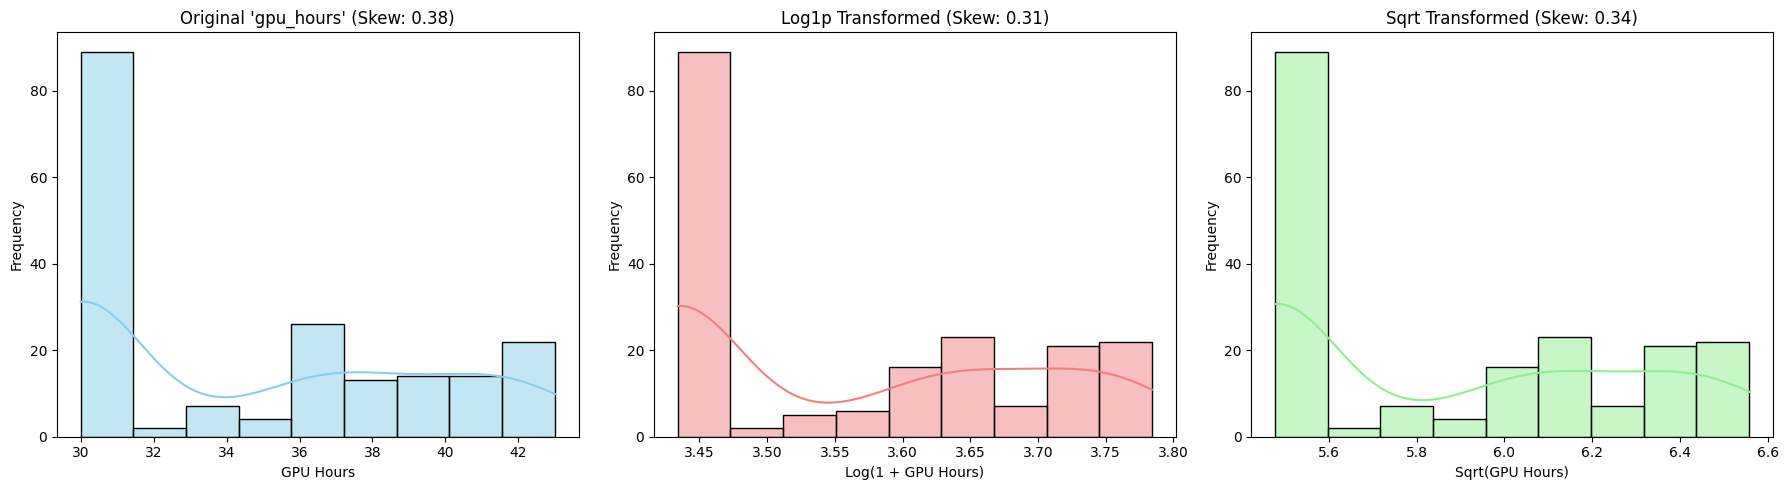

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'gpu_hours' in df.columns:
    data_skew = df['gpu_hours'].copy()
    transformed_data_log = np.log1p(data_skew)
    transformed_data_sqrt = np.sqrt(data_skew)

    # Plot histograms to visualize skewness before and after transformation
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Original data histogram
    sns.histplot(data_skew, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f"Original 'gpu_hours' (Skew: {data_skew.skew():.2f})")
    axes[0].set_xlabel('GPU Hours')
    axes[0].set_ylabel('Frequency')

    # Log transformed data histogram
    sns.histplot(transformed_data_log, kde=True, ax=axes[1], color='lightcoral')
    axes[1].set_title(f"Log1p Transformed (Skew: {transformed_data_log.skew():.2f})")
    axes[1].set_xlabel('Log(1 + GPU Hours)')
    axes[1].set_ylabel('Frequency')

    # Square root transformed data histogram
    sns.histplot(transformed_data_sqrt, kde=True, ax=axes[2], color='lightgreen')
    axes[2].set_title(f"Sqrt Transformed (Skew: {transformed_data_sqrt.skew():.2f})")
    axes[2].set_xlabel('Sqrt(GPU Hours)')
    axes[2].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot generate diagrams as 'gpu_hours' column is not available.")


### Diagnosis

Diagnosing skewness is crucial for ensuring the validity of statistical assumptions and the robustness of financial models. Several methods can be used to detect and quantify skewness:

1.  **Visual Inspection (Histograms and Density Plots)**: The most intuitive way to detect skewness is to plot the distribution of the data using a histogram or a kernel density estimate (KDE) plot. A visually elongated tail to the right indicates positive skew, while a longer tail to the left indicates negative skew.

2.  **Skewness Coefficient**: Calculate the skewness coefficient directly. Python's `scipy.stats.skew` or pandas' `DataFrame.skew()` method can provide this value.
    *   A value of 0 indicates perfectly symmetric data.
    *   Positive values indicate positive (right) skew.
    *   Negative values indicate negative (left) skew.
    *   Typically, a skewness value greater than +1 or less than -1 is considered highly skewed; values between +0.5 and -0.5 are generally considered approximately symmetric.

3.  **Comparison of Mean, Median, and Mode**:
    *   For a perfectly symmetric distribution, Mean = Median = Mode.
    *   For positively skewed data, Mode < Median < Mean.
    *   For negatively skewed data, Mean < Median < Mode.

4.  **Q-Q Plots (Quantile-Quantile Plots)**: A Q-Q plot compares the quantiles of your data distribution against the quantiles of a theoretical distribution (e.g., a normal distribution). If the data points deviate significantly from the straight line in a Q-Q plot, it suggests non-normality, which often includes skewness. Curvature in the Q-Q plot can indicate the direction of skewness.

### Damage

Skewness, particularly in financial time series data like asset returns or volatility measures, can lead to several problems and biases in modeling and analysis:

1.  **Violation of Statistical Assumptions**: Many classical statistical tests (e.g., t-tests, ANOVA) and regression models assume that the data (or residuals) are normally distributed, which implies zero skewness. Violating this assumption can lead to incorrect p-values, confidence intervals, and thus, erroneous conclusions.

2.  **Biased Parameter Estimates**: In financial models, if input variables are skewed but assumed to be normal, the estimated parameters (e.g., mean, variance, correlations) can be biased, leading to inaccurate forecasts or risk assessments.

3.  **Misleading Interpretation of Central Tendency**: When data is skewed, the mean can be pulled towards the long tail, making it a poor representation of the 'typical' value. For example, in positively skewed income distributions, the mean income might be higher than what most people earn, as it's influenced by a few high earners.

4.  **Impact on Risk Management**:
    *   **Value at Risk (VaR)**: If a distribution of returns is negatively skewed (meaning larger downside movements are more frequent or severe than assumed by a normal distribution), a VaR model based on normality might underestimate potential losses.
    *   **Option Pricing**: The Black-Scholes model assumes normally distributed asset returns. If actual returns are skewed, the model will systematically misprice options, especially out-of-the-money options. More advanced models (like jump-diffusion models or those incorporating stochastic volatility) are needed to account for skewness.

5.  **Inefficient Modeling**: Linear models might struggle to capture the non-linear relationships often implied by skewed distributions, leading to suboptimal model performance (e.g., lower $R^2$, higher prediction errors).

6.  **Incorrect Inferential Statistics**: Hypothesis tests and confidence intervals constructed under the assumption of symmetry will be inaccurate, potentially leading to wrong decisions in trading, portfolio allocation, or risk mitigation strategies.

### Directions

Addressing skewness in data is essential for building more robust and reliable statistical and machine learning models, especially in finance. Here are several strategies:

1.  **Data Transformations**: The most common approach is to apply mathematical transformations to the skewed variable to make its distribution more symmetric (closer to normal). Common transformations include:
    *   **Log Transformation (log or log1p)**: Useful for positively skewed data. It compresses the larger values and expands the smaller values. `np.log(x)` or `np.log1p(x)` (for data that might contain zeros).
    *   **Square Root Transformation (sqrt)**: Also effective for positively skewed data, though less aggressive than the log transformation. `np.sqrt(x)`.
    *   **Reciprocal Transformation (1/x)**: Can be used for highly positively skewed data, but reverses the order of values.
    *   **Box-Cox Transformation**: A parameterized power transformation that can be applied to non-negative data. It can stabilize variance and normalize distributions. It can determine the optimal power exponent ($\lambda$) to make the data approximately normal.

2.  **Use Non-Parametric Methods**: If transformations don't sufficiently normalize the data, or if the underlying distribution is fundamentally non-normal, consider using non-parametric statistical tests or models that do not rely on assumptions about the distribution's shape. Examples include permutation tests, bootstrap methods, or rank-based tests.

3.  **Robust Regression Techniques**: Techniques like robust regression are less sensitive to outliers and departures from normality in the residuals, which can arise from skewed predictors or response variables.

4.  **Tree-Based Models**: Algorithms like Decision Trees, Random Forests, and Gradient Boosting Machines (e.g., XGBoost, LightGBM) are generally less sensitive to the distribution of individual features because they make decisions based on splits rather than assuming linearity or normality.

5.  **Data Generation/Augmentation**: In some cases, if the skewness is due to insufficient data at the tails, acquiring more data might help. Synthetic data generation techniques could also be explored carefully.

6.  **Domain Knowledge**: Always consider the context. Sometimes, skewness is a natural and important characteristic of the data (e.g., income distribution), and forcing it into symmetry might remove valuable information. In such cases, models that explicitly account for skewness (e.g., GARCH models with skewed t-distributions for financial returns) might be more appropriate.

## 4. Prioritizing Factors

### Definition
Prioritizing factors in volatility modeling involves identifying and ranking the most influential variables that drive changes in an asset's price volatility or other relevant time series. This process is crucial for model simplification, risk management, and strategic decision-making. It aims to distinguish between factors that have a significant, robust impact and those with negligible or spurious effects.

### Description
In financial time series analysis, especially for volatility, numerous potential factors can be considered. These might include historical price movements, trading volume, economic indicators, news sentiment, and more. Prioritizing these factors means understanding their relative importance in explaining or forecasting volatility.

Key aspects of factor prioritization include:
*   **Statistical Significance**: Factors with statistically significant coefficients in a regression model are typically considered more important.
*   **Economic Significance/Magnitude**: Even if statistically significant, a factor's practical importance depends on the magnitude of its effect. Standardized coefficients can help compare the relative impact of factors on different scales.
*   **Domain Expertise**: Industry knowledge and theoretical understanding are vital to guide factor selection and interpretation.
*   **Model Performance Impact**: Removing or including a factor should demonstrably improve or degrade model performance (e.g., lower prediction error, higher R-squared).
*   **Robustness**: An important factor should consistently show its influence across different datasets, time periods, and model specifications.

### Demonstration

In [12]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Assuming 'df' and 'X_cols', 'y_col' are defined from the multicollinearity section
# For this demonstration, we'll explicitly use the features and target created previously.

if 'Feature1_GPU' in df.columns and 'Target_GPU' in df.columns:
    X_factors = df[['Feature1_GPU', 'Feature2_Correlated_GPU', 'Feature3_Independent']]
    y_target = df['Target_GPU']

    # Standardize the features to make coefficients comparable
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_factors)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X_factors.columns, index=X_factors.index)

    # Add a constant for the intercept term
    X_scaled_df = sm.add_constant(X_scaled_df)

    # Fit the OLS model with standardized features
    model_prioritization = sm.OLS(y_target, X_scaled_df).fit()

    print("\nOLS Regression Results with Standardized Features:")
    print(model_prioritization.summary())

    # Extract coefficients and p-values
    coefficients = model_prioritization.params.drop('const') # Exclude intercept
    p_values = model_prioritization.pvalues.drop('const')

    print("\nCoefficients and p-values for Factor Prioritization:")
    results_df = pd.DataFrame({'Coefficient': coefficients, 'P-value': p_values})
    display(results_df.sort_values(by='Coefficient', ascending=False))

    # Note: For non-linear models, other methods like feature importance from tree-based models
    # or permutation importance would be used.

else:
    print("Required 'Feature1_GPU' and 'Target_GPU' columns not found for demonstration.")
    print("Please ensure the DataFrame contains the necessary columns from previous steps.")



OLS Regression Results with Standardized Features:
                            OLS Regression Results                            
Dep. Variable:             Target_GPU   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     29.09
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.75e-15
Time:                        08:35:20   Log-Likelihood:                -575.77
No. Observations:                 191   AIC:                             1160.
Df Residuals:                     187   BIC:                             1173.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

,Coefficient,P-value
Feature1_GPU,6.948662,0.049325
Feature3_Independent,0.658632,0.070016
Feature2_Correlated_GPU,-3.717816,0.291235


### Diagram

/tmp/ipykernel_4490/4229103372.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.index, y=coefficients.values, ax=ax, palette='viridis')


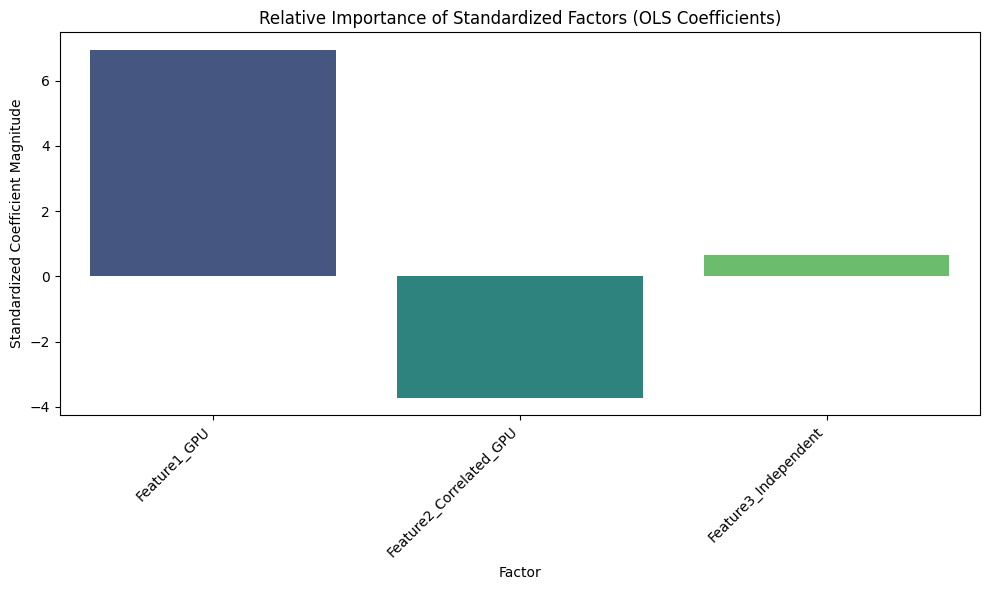

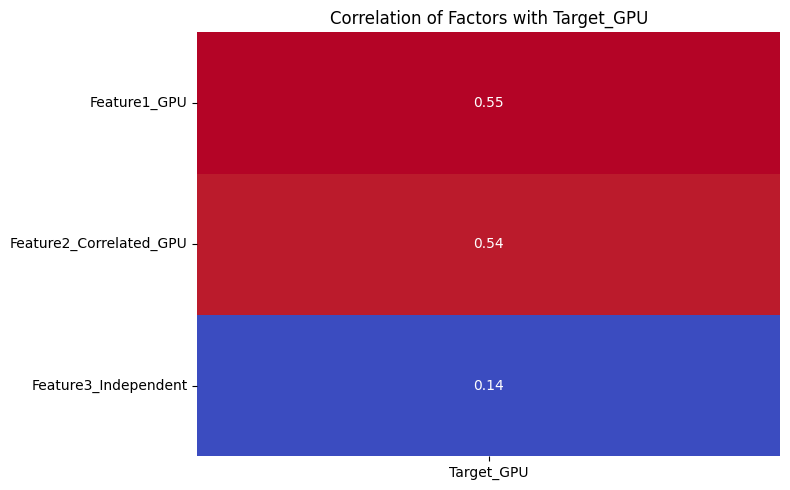

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'Feature1_GPU' in df.columns and 'Target_GPU' in df.columns:
    X_factors = df[['Feature1_GPU', 'Feature2_Correlated_GPU', 'Feature3_Independent']]
    y_target = df['Target_GPU']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_factors)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X_factors.columns, index=X_factors.index)
    X_scaled_df = sm.add_constant(X_scaled_df)
    model_prioritization = sm.OLS(y_target, X_scaled_df).fit()

    coefficients = model_prioritization.params.drop('const')

    # Plotting coefficients to visualize importance
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=coefficients.index, y=coefficients.values, ax=ax, palette='viridis')
    ax.set_title('Relative Importance of Standardized Factors (OLS Coefficients)')
    ax.set_xlabel('Factor')
    ax.set_ylabel('Standardized Coefficient Magnitude')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Also, a heatmap of correlations with the target can provide initial insights
    corr_with_target = df[['Feature1_GPU', 'Feature2_Correlated_GPU', 'Feature3_Independent', 'Target_GPU']].corr()['Target_GPU'][:-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(corr_with_target.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
    ax.set_title('Correlation of Factors with Target_GPU')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot generate diagrams as required columns are not available.")


### Diagnosis

Diagnosing and establishing factor priority requires a rigorous approach:

1.  **Statistical Significance Tests**: Examine p-values of regression coefficients. Factors with p-values below a chosen significance level (e.g., 0.05) are statistically significant.

2.  **Coefficient Magnitudes (Standardized)**: For linear models, comparing the absolute magnitudes of standardized coefficients allows for direct comparison of each factor's impact on the dependent variable, independent of their original scales.

3.  **Feature Importance from Machine Learning Models**: For non-linear or complex models (e.g., tree-based models like Random Forests, XGBoost), built-in feature importance scores (e.g., Gini importance, gain) or permutation importance are commonly used.

4.  **Sensitivity Analysis**: Assess how model outputs change with small variations in input factors. Factors that lead to large changes are more influential.

5.  **Information Criteria (AIC, BIC)**: These criteria balance model fit with complexity. A model with fewer, high-priority factors that performs well on these metrics might be preferred.

6.  **Domain Expertise**: Engage with subject matter experts to validate statistical findings. Sometimes, a statistically insignificant factor might be deemed important due to expert knowledge and vice-versa.

### Damage

Misjudging factor priorities can lead to several detrimental outcomes in volatility modeling:

1.  **Suboptimal Model Performance**: Including irrelevant factors can introduce noise and increase model complexity without adding predictive power, potentially leading to overfitting. Conversely, excluding truly important factors results in underfitting and poor predictive accuracy.

2.  **Inefficient Resource Allocation**: If significant resources are spent on collecting, cleaning, and processing data for factors that have little impact, it's a waste of time and computational power.

3.  **Misleading Interpretations and Decisions**: Incorrectly identifying drivers of volatility can lead to flawed insights into market behavior, resulting in poor trading strategies, incorrect risk assessments, and misinformed hedging decisions.

4.  **Increased Model Risk**: Overly complex models with many factors, some of which are irrelevant, are harder to understand, validate, and maintain. This increases model risk, especially in regulated environments where model interpretability and transparency are paramount.

5.  **Lack of Focus**: Without clear prioritization, efforts might be scattered across too many factors, diluting the impact of analysis and development.

### Directions

Effectively prioritizing factors involves a combination of statistical techniques, domain knowledge, and iterative refinement:

1.  **Start with Domain Knowledge**: Begin by leveraging expert insights into which factors are theoretically expected to influence volatility. This helps form initial hypotheses.

2.  **Exploratory Data Analysis (EDA)**: Use correlation analysis, scatter plots, and other visualizations to identify potential relationships between factors and the target variable.

3.  **Univariate Analysis**: Examine the individual impact of each factor on volatility. Simple linear regressions can provide initial insights into individual factor significance.

4.  **Multivariate Modeling and Feature Selection**: Build multivariate models (e.g., OLS, GARCH, machine learning models) and use formal feature selection techniques:
    *   **Stepwise Regression**: (Use with caution) Automatically adds or removes predictors based on statistical criteria.
    *   **Regularization (Lasso, Ridge)**: Lasso (L1) regression can perform feature selection by shrinking coefficients of less important features to zero.
    *   **Feature Importance from ML Models**: Extract importance scores from models like Random Forests, Gradient Boosting Machines.
    *   **Permutation Importance**: A model-agnostic technique that measures the decrease in model performance when a single feature's values are randomly shuffled, breaking its relationship with the target.

5.  **Cross-Validation**: Use cross-validation to assess the robustness of factor importance across different data subsets and to prevent overfitting.

6.  **Standardization/Normalization**: For linear models, standardize numerical features before model fitting to ensure that coefficients reflect relative importance accurately.

7.  **Iterative Refinement**: Prioritization is often an iterative process. Build initial models, assess factor importance, refine the set of factors, and re-evaluate.

8.  **Regular Monitoring**: Factor importance can change over time due to market regime shifts or structural changes. Regularly monitor and re-evaluate factor priorities.

## Summary of Best-Practices Handbook for Volatility Modeling

This handbook provides a comprehensive overview of four critical time series problems encountered in volatility modeling: Overfitting, Multicollinearity, Skewness, and Prioritizing Factors. For each problem, it delineates the Definition, Description, Demonstration, Diagram, Diagnosis, Damage, and Directions for mitigation.

### Overfitting

**Definition and Description:** Overfitting occurs when a model learns the training data too precisely, capturing noise rather than general patterns, leading to poor generalization on unseen data (cell cdd50f15). The demonstration uses synthetic data with polynomial regression to visually contrast underfitted, good fit, and overfitted models, showing how high-degree polynomials can memorize training data but fail on test data (cells b45b31c7, 53c0fd2f).

**Diagnosis:** Key indicators include high training accuracy with low test accuracy, model complexity, visual inspection for erratic fits, and inconsistent cross-validation performance (cell e84bbfc7).

**Damage:** Overfitting results in unreliable predictions, poor generalizability, wasted resources, and potential loss of trust in models (cell 09aeff2c).

**Directions:** Strategies include using more data, feature selection, regularization (L1/L2), cross-validation, simpler models, early stopping, and ensemble methods (cell 1b676187).

### Multicollinearity

**Definition and Description:** Multicollinearity describes a high correlation between two or more predictor variables in a multiple regression model, leading to unstable and unreliable coefficient estimates (cell 35542029). The demonstration uses the `kaggle-weekly-gpu-quotas` dataset (`kaggle_gpu_hours.csv`), creating synthetic correlated features from 'gpu_hours' to illustrate the impact on OLS regression coefficients when highly correlated features are present versus when one is removed (cells 27b74358, b9c973da).

**Diagnosis:** Diagnosed by high correlation coefficients between predictors, Variance Inflation Factor (VIF) values above 5 or 10, significant changes in coefficients upon variable addition/removal, large standard errors, and statistically insignificant individual p-values despite a high overall R-squared (cell 7788fc52).

**Damage:** Leads to unreliable coefficient estimates, inflated standard errors, difficulty in interpretation, reduced statistical power, and potentially poor out-of-sample generalization (cell aa5e8718).

**Directions:** Mitigation strategies include removing one of the correlated variables, combining them, using Principal Component Analysis (PCA), applying regularization techniques (Ridge or Lasso), collecting more data, and leveraging domain knowledge (cell 691fc8e4).

### Skewness

**Definition and Description:** Skewness measures the asymmetry of a distribution, indicating if one tail is longer than the other. Positive skew (mean > median) has a longer right tail, while negative skew (mean < median) has a longer left tail. Many statistical methods assume zero skewness (cells 337ce18a, 27767cf8).

**Demonstration:** Using the 'gpu_hours' column from the `kaggle-weekly-gpu-quotas` dataset, the handbook calculates original skewness and demonstrates how `log1p` and square root transformations can reduce it, visualizing the effect with histograms (cells f6a78a3c, bbdd0fba).

**Diagnosis:** Identified through visual inspection of histograms, calculation of skewness coefficients (where values > |1| are highly skewed), comparison of mean, median, and mode, and Q-Q plots (cell 0f547075).

**Damage:** Violates statistical assumptions, biases parameter estimates, misleads interpretation of central tendency, impacts risk management (e.g., VaR, option pricing), leads to inefficient modeling, and provides incorrect inferential statistics (cell 391412a2).

**Directions:** Addressed by data transformations (log, square root, Box-Cox), using non-parametric methods, employing robust regression techniques, utilizing tree-based models, data generation/augmentation, and considering domain knowledge (cell 319a3a6f).

### Prioritizing Factors

**Definition and Description:** This involves identifying and ranking the most influential variables driving volatility changes for model simplification, risk management, and decision-making. Key aspects include statistical significance, economic significance/magnitude, domain expertise, model performance impact, and robustness (cells 3e3408f4, 8280846e).

**Demonstration:** Using the synthetically generated features from the `kaggle-weekly-gpu-quotas` dataset, the demonstration performs OLS regression with standardized features to show how coefficients and p-values can indicate relative factor importance. It also visualizes standardized coefficients and correlations with the target (cells 37da79dc, 7d115d94, 445facd7).

**Diagnosis:** Diagnosed using statistical significance tests (p-values), magnitudes of standardized coefficients, feature importance from ML models, sensitivity analysis, information criteria (AIC, BIC), and domain expertise (cell d03755aa).

**Damage:** Leads to suboptimal model performance (overfitting/underfitting), inefficient resource allocation, misleading interpretations, increased model risk, and a lack of focus (cell 83bbce1f).

**Directions:** Involves starting with domain knowledge, exploratory data analysis (EDA), univariate analysis, multivariate modeling with feature selection (stepwise regression, regularization, ML feature importance, permutation importance), cross-validation, standardization, iterative refinement, and regular monitoring (cell 1c29deef).

---

## References

Colab Notebook. *Overfitting: Definition and Description*, [Cell ID: cdd50f15]. Available in current notebook.
Colab Notebook. *Overfitting: Demonstration (Code - Part 1)*, [Cell ID: b45b31c7]. Available in current notebook.
Colab Notebook. *Overfitting: Demonstration (Code - Part 2)*, [Cell ID: 53c0fd2f]. Available in current notebook.
Colab Notebook. *Overfitting: Diagnosis*, [Cell ID: e84bbfc7]. Available in current notebook.
Colab Notebook. *Overfitting: Damage*, [Cell ID: 09aeff2c]. Available in current notebook.
Colab Notebook. *Overfitting: Directions*, [Cell ID: 1b676187]. Available in current notebook.

Colab Notebook. *Multicollinearity: Definition and Description*, [Cell ID: 35542029]. Available in current notebook.
Colab Notebook. *Multicollinearity: Demonstration (Data Loading)*, [Cell ID: 27b74358]. Available in current notebook.
Colab Notebook. *Multicollinearity: Demonstration (Regression Analysis)*, [Cell ID: b9c973da]. Available in current notebook.
Colab Notebook. *Multicollinearity: Diagnosis*, [Cell ID: 7788fc52]. Available in current notebook.
Colab Notebook. *Multicollinearity: Damage*, [Cell ID: aa5e8718]. Available in current notebook.
Colab Notebook. *Multicollinearity: Directions*, [Cell ID: 691fc8e4]. Available in current notebook.

Colab Notebook. *Skewness: Definition*, [Cell ID: 337ce18a]. Available in current notebook.
Colab Notebook. *Skewness: Description*, [Cell ID: 27767cf8]. Available in current notebook.
Colab Notebook. *Skewness: Demonstration (Numerical Results)*, [Cell ID: f6a78a3c]. Available in current notebook.
Colab Notebook. *Skewness: Demonstration (Diagrams)*, [Cell ID: bbdd0fba]. Available in current notebook.
Colab Notebook. *Skewness: Diagnosis*, [Cell ID: 0f547075]. Available in current notebook.
Colab Notebook. *Skewness: Damage*, [Cell ID: 391412a2]. Available in current notebook.
Colab Notebook. *Skewness: Directions*, [Cell ID: 319a3a6f]. Available in current notebook.

Colab Notebook. *Prioritizing Factors: Definition*, [Cell ID: 3e3408f4]. Available in current notebook.
Colab Notebook. *Prioritizing Factors: Description*, [Cell ID: 8280846e]. Available in current notebook.
Colab Notebook. *Prioritizing Factors: Demonstration (OLS Regression)*, [Cell IDs: 37da79dc, 7d115d94]. Available in current notebook.
Colab Notebook. *Prioritizing Factors: Demonstration (Diagrams)*, [Cell ID: 445facd7]. Available in current notebook.
Colab Notebook. *Prioritizing Factors: Diagnosis*, [Cell ID: d03755aa]. Available in current notebook.
Colab Notebook. *Prioritizing Factors: Damage*, [Cell ID: 83bbce1f]. Available in current notebook.
Colab Notebook. *Prioritizing Factors: Directions*, [Cell ID: 1c29deef]. Available in current notebook.
